# 02 - Data Cleaning

## Price Intelligence Platform

Ce notebook correspond à la phase de nettoyage des données. Il transforme les données observées dans `01_data_understanding.ipynb` en un dataset propre, exploitable pour l'analyse exploratoire, les tests statistiques et les dashboards.

**Objectifs :**

- standardiser les colonnes importantes,
- valider les types de données,
- traiter les valeurs manquantes,
- détecter et gérer les outliers,
- sauvegarder un dataset nettoyé et documenté.


## Source officielle mise à jour

Après le dernier merge, la source officielle des données est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Le notebook charge BigQuery en priorité. Si l'accès BigQuery n'est pas disponible dans Anaconda, il utilise un snapshot CSV exporté dans `outputs/raw_data/bigquery_products_export.csv`. Le fallback local JSON ne doit servir qu'au développement offline.


## BigQuery obligatoire

Ce notebook ne doit plus utiliser les anciens JSON locaux. La source officielle est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Si BigQuery n’est pas accessible depuis Anaconda, exporte la table BigQuery en CSV et place le fichier ici :

```text
C:\Users\Admin\Desktop\data-analysis\outputs\raw_data\bigquery_products_export.csv
```

Le notebook utilisera ce snapshot BigQuery. Sans accès BigQuery et sans export CSV, il s’arrêtera au lieu de reprendre les anciennes données locales.


## 1. Méthodologie de nettoyage

Dans cette phase, nous ne supprimons pas arbitrairement les données. Chaque décision doit être justifiée.

Méthode utilisée :

1. Charger les données validées de base.
2. Standardiser les champs texte (`store`, `category`, `availability`, `name`).
3. Convertir les variables numériques (`price`, `discount`, `stars`).
4. Convertir la date de scraping.
5. Détecter les outliers avec la méthode IQR.
6. Créer deux datasets :
   - `df_clean_full` : données nettoyées avec outliers marqués,
   - `df_clean_no_outliers` : données nettoyées sans outliers pour les analyses robustes.

## 2. Imports et configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def find_data_analysis_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates += [candidate / "data-analysis" for candidate in candidates]
    for candidate in candidates:
        if (candidate / "price_analysis.py").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Impossible de trouver le dossier data-analysis. Ouvre le notebook depuis data-analysis ou depuis le repo price-intelligence.")

DATA_ANALYSIS_DIR = find_data_analysis_root()
PROJECT_ROOT = DATA_ANALYSIS_DIR.parent

if str(DATA_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_ANALYSIS_DIR))

import price_analysis as pa

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

print("Dossier de travail Data Analysis :", DATA_ANALYSIS_DIR)
print("Dossier source du projet :", PROJECT_ROOT)


Dossier de travail Data Analysis : C:\Users\Admin\Desktop\price-intelligence\data-analysis
Dossier source du projet : C:\Users\Admin\Desktop\price-intelligence


## 3. Configuration de l'auto-sauvegarde

In [2]:
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"
OUTPUT_CLEANED = OUTPUTS_DIR / "cleaned_data"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)
OUTPUT_CLEANED.mkdir(parents=True, exist_ok=True)

AUTO_SAVE = True

print("Auto-sauvegarde activée :", AUTO_SAVE)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des graphiques :", OUTPUT_FIGURES)
print("Dossier des données nettoyées :", OUTPUT_CLEANED)

Auto-sauvegarde activée : True
Dossier des tableaux : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Dossier des graphiques : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures
Dossier des données nettoyées : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\cleaned_data


In [3]:

EXPECTED_MIN_RAW_ROWS = 20000
EXPECTED_STORE = "sport-direct"
EXPECTED_MAX_NULL_PRICE = 500

def assert_official_bigquery_data(raw_df, cleaned_df=None, source=None):
    stores = set(raw_df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    null_price = raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else None
    if source is not None and source != "bigquery_live":
        raise ValueError(f"Source invalide: {source}. Le notebook doit utiliser BigQuery live, pas un ancien export/local.")
    if len(raw_df) < EXPECTED_MIN_RAW_ROWS:
        raise ValueError(f"Dataset trop petit ({len(raw_df)} lignes). Anciennes donnees detectees: recharge depuis BigQuery live.")
    if EXPECTED_STORE not in stores:
        raise ValueError(f"Store {EXPECTED_STORE} absent. Anciennes donnees detectees ou notebook non relance depuis BigQuery.")
    if null_price is not None and null_price > EXPECTED_MAX_NULL_PRICE:
        raise ValueError(f"Trop de prix null ({null_price}). Verifie la table BigQuery source.")
    if cleaned_df is not None and len(cleaned_df) < 15000:
        raise ValueError(f"Dataset nettoye trop petit ({len(cleaned_df)} lignes). Relance 02_data_cleaning.ipynb avec BigQuery live.")


## 4. Chargement des données

In [4]:
# Securite : BigQuery live obligatoire pour eviter les anciennes donnees
DATA_SOURCE = "bigquery"
BQ_TABLE = "price-intelligence-495411.price_intelligence.products"
RAW_EXPORT_PATH = DATA_ANALYSIS_DIR / "outputs" / "raw_data" / "bigquery_products_export.csv"

raw_rows, effective_source = pa.load_project_rows(
    source=DATA_SOURCE,
    table_id=BQ_TABLE,
    project_root=PROJECT_ROOT,
    export_path=RAW_EXPORT_PATH,
    allow_export_fallback=False,
    allow_local_fallback=False,
)
raw_df = pd.DataFrame(raw_rows)
rows = pa.normalize_rows(raw_rows)
df_raw = pd.DataFrame(rows)
df = df_raw

assert_official_bigquery_data(raw_df, df, effective_source)

print("Source utilisee :", effective_source)
print("Table BigQuery officielle :", BQ_TABLE)
print("Nombre total de lignes brutes chargees :", len(raw_rows))
print("Nombre de lignes apres validation de base du prix :", len(df))
print("Lignes brutes avec name null :", raw_df["name"].isna().sum() if "name" in raw_df.columns else "colonne absente")
print("Lignes brutes avec current_price null :", raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else "colonne absente")
print("Plateformes detectees :", sorted(raw_df["store"].dropna().astype(str).str.lower().unique()) if "store" in raw_df.columns else "colonne absente")

df.head()


Source utilisee : bigquery_live
Table BigQuery officielle : price-intelligence-495411.price_intelligence.products
Nombre total de lignes brutes chargees : 23358
Nombre de lignes apres validation de base du prix : 23166
Lignes brutes avec name null : 192
Lignes brutes avec current_price null : 192
Plateformes detectees : ['ebay', 'jumia', 'sport-direct', 'unknown']


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at
0,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-15T22:09:41.674252
1,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-15T22:09:41.674252
2,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884
3,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884
4,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,In Stock,2026-05-16T13:11:38.818884


## 5. Copie de travail et audit initial

In [5]:
df = df_raw.copy()

audit_initial = pd.DataFrame({
    "metric": ["lignes_initiales", "colonnes_initiales", "produits_uniques_nom", "plateformes", "categories"],
    "value": [
        df.shape[0],
        df.shape[1],
        df["name"].nunique(),
        df["store"].nunique(),
        df["category"].nunique(),
    ]
})

print("Audit initial du dataset :")
audit_initial

Audit initial du dataset :


,metric,value
0,lignes_initiales,23166
1,colonnes_initiales,9
2,produits_uniques_nom,3569
3,plateformes,3
4,categories,7


## 6. Standardisation des colonnes texte

In [6]:
df["store"] = df["store"].astype(str).str.strip().str.lower()
df["category"] = df["category"].astype(str).str.strip().str.lower()
df["name"] = df["name"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["availability"] = df["availability"].astype(str).str.strip().str.lower()

# Harmonisation légère des disponibilités vides
df["availability"] = df["availability"].replace({"": "unknown", "nan": "unknown", "none": "unknown"})

print("Plateformes après standardisation :", sorted(df["store"].unique()))
print("Catégories après standardisation :", sorted(df["category"].unique()))
df[["store", "category", "name", "availability"]].head()

Plateformes après standardisation : ['ebay', 'jumia', 'sport-direct']
Catégories après standardisation : ['basketball', 'combat-sports', 'football', 'gym', 'racket-sports', 'unknown', 'volleyball']


,store,category,name,availability
0,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,in stock
1,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,in stock
2,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,in stock
3,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,in stock
4,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,in stock


## 7. Validation des variables numériques

In [7]:
numeric_columns = ["price", "price_before_discount", "discount", "stars"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Règles de qualité simples
df.loc[df["price"] <= 0, "price"] = np.nan
df.loc[(df["discount"] < 0) | (df["discount"] > 100), "discount"] = np.nan
df.loc[(df["stars"] < 0) | (df["stars"] > 5), "stars"] = np.nan

print("Résumé des variables numériques après validation :")
df[numeric_columns].describe().T

Résumé des variables numériques après validation :


,count,mean,std,min,25%,50%,75%,max
price,23166.0,488.469998,805.561693,9.0,129.31,269.0,559.0,35612.5
price_before_discount,6882.0,443.388503,428.161912,35.0,180.00,299.0,520.0,3000.0
discount,6882.0,36.741790,17.379561,1.0,25.00,36.0,49.0,90.0
stars,23166.0,0.524225,1.405734,0.0,0.00,0.0,0.0,5.0


## 8. Conversion de la date de scraping

In [8]:
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")
df["scraped_date"] = df["scraped_at"].dt.date

print("Nombre de dates valides :", df["scraped_at"].notna().sum())
print("Nombre de dates invalides/manquantes :", df["scraped_at"].isna().sum())
print("Période couverte :", df["scraped_at"].min(), "->", df["scraped_at"].max())

Nombre de dates valides : 23166
Nombre de dates invalides/manquantes : 0
Période couverte : 2026-05-15 16:50:34.465926 -> 2026-05-20 13:09:12.082398


## 9. Analyse des valeurs manquantes après standardisation

In [9]:
missing_after_standardization = df.isna().sum().reset_index()
missing_after_standardization.columns = ["colonne", "nombre_valeurs_manquantes"]
missing_after_standardization["taux_valeurs_manquantes"] = missing_after_standardization["nombre_valeurs_manquantes"] / len(df)

print("Valeurs manquantes après standardisation :")
missing_after_standardization.sort_values("taux_valeurs_manquantes", ascending=False)

Valeurs manquantes après standardisation :


,colonne,nombre_valeurs_manquantes,taux_valeurs_manquantes
4,price_before_discount,16284,0.702927
5,discount,16284,0.702927
1,category,0,0.000000
0,store,0,0.000000
3,price,0,0.000000
2,name,0,0.000000
6,stars,0,0.000000
7,availability,0,0.000000
8,scraped_at,0,0.000000
9,scraped_date,0,0.000000


## 10. Traitement des valeurs manquantes

Décisions retenues :

- `price` est obligatoire pour l'analyse : les lignes sans prix valide sont supprimées.
- `discount` peut être manquant : on garde la valeur manquante pour ne pas inventer une remise.
- `stars` peut être manquant : on garde la valeur manquante pour éviter une fausse moyenne.
- `availability` manquante est remplacée par `unknown`.
- `scraped_at` manquante est conservée mais documentée.

In [10]:
rows_before_required_filters = len(df)

df = df.dropna(subset=["price", "store", "category", "name"]).copy()
df = df[df["name"].str.len() > 0].copy()

rows_after_required_filters = len(df)
print("Lignes avant filtres obligatoires :", rows_before_required_filters)
print("Lignes après filtres obligatoires :", rows_after_required_filters)
print("Lignes supprimées :", rows_before_required_filters - rows_after_required_filters)

Lignes avant filtres obligatoires : 23166
Lignes après filtres obligatoires : 23166
Lignes supprimées : 0


## 11. Détection des doublons

In [11]:
duplicate_mask = df.duplicated(subset=["store", "category", "name", "price"], keep="first")
duplicate_count = duplicate_mask.sum()

print("Nombre de doublons détectés sur store/category/name/price :", duplicate_count)
df_duplicates = df[duplicate_mask].copy()
df_duplicates.head()

Nombre de doublons détectés sur store/category/name/price : 17848


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at,scraped_date
1,ebay,unknown,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,in stock,2026-05-15 22:09:41.674252,2026-05-15
3,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,in stock,2026-05-16 13:11:38.818884,2026-05-16
4,ebay,gym,Nutricost Whey Protein Isolate (Vanilla) 5LBS ...,915.57,NaN,NaN,5.0,in stock,2026-05-16 13:11:38.818884,2026-05-16
6,ebay,unknown,Nutricost Whey Protein Isolate (Chocolate) 2LB...,462.31,NaN,NaN,0.0,in stock,2026-05-15 22:09:41.863273,2026-05-15
8,ebay,gym,Nutricost Whey Protein Isolate (Chocolate) 2LB...,462.31,NaN,NaN,0.0,in stock,2026-05-16 13:11:38.849310,2026-05-16


In [12]:
rows_before_dedup = len(df)
df = df.drop_duplicates(subset=["store", "category", "name", "price"], keep="first").copy()
rows_after_dedup = len(df)

print("Lignes avant suppression des doublons :", rows_before_dedup)
print("Lignes après suppression des doublons :", rows_after_dedup)
print("Doublons supprimés :", rows_before_dedup - rows_after_dedup)

Lignes avant suppression des doublons : 23166
Lignes après suppression des doublons : 5318
Doublons supprimés : 17848


## 12. Détection des outliers avec la méthode IQR

La phase précédente a montré des prix extrêmes. On utilise la méthode IQR pour les détecter. Les outliers ne sont pas simplement effacés : ils sont marqués dans `df_clean_full`, puis exclus dans une version séparée `df_clean_no_outliers` pour les analyses robustes.

In [13]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("Q1 :", round(q1, 2))
print("Q3 :", round(q3, 2))
print("IQR :", round(iqr, 2))
print("Limite inférieure :", round(lower_limit, 2))
print("Limite supérieure :", round(upper_limit, 2))

Q1 : 161.69
Q3 : 725.77
IQR : 564.08
Limite inférieure : -684.43
Limite supérieure : 1571.9


In [14]:
df["is_price_outlier"] = (df["price"] < lower_limit) | (df["price"] > upper_limit)

outlier_count = df["is_price_outlier"].sum()
outlier_rate = outlier_count / len(df)

print("Nombre d'outliers prix détectés :", outlier_count)
print("Taux d'outliers prix :", round(outlier_rate * 100, 2), "%")

df[df["is_price_outlier"]].sort_values("price", ascending=False)[
    ["store", "category", "price", "name"]
].head(15)

Nombre d'outliers prix détectés : 428
Taux d'outliers prix : 8.05 %


,store,category,price,name
10159,ebay,unknown,35612.50,​1970/73 NY Knicks Championship Autographed Ba...
21598,ebay,basketball,17527.73,Size 10 - Jordan 1 Retro OG x Off-White High C...
21192,ebay,basketball,14032.25,DM7866-140 Travis Scott fragment design Nike A...
6044,ebay,unknown,11562.50,Nike Air Jordan 1 Low OG SP Travis Scott Rever...
1617,ebay,basketball,9249.91,NBA Victor Wembenyama Autographed Basketball W...
404,ebay,football,9249.91,Nike Tiempo Legend VI 6 Elite Totti x Roma Gol...
4459,ebay,basketball,8325.00,Tyrese Haliburton Signed & Multi-Inscribed Wil...
5929,ebay,unknown,8313.99,Zinedine Zidane Signed France Soccer Ball Real...
4875,ebay,unknown,8313.99,Zinedine Zidane Signed Adidas Soccer Ball Juve...
6356,ebay,football,8313.99,Zinedine Zidane Signed Adidas Soccer Ball Real...


## 13. Comparaison avant / après retrait des outliers

In [15]:
df_clean_full = df.copy()
df_clean_no_outliers = df[~df["is_price_outlier"]].copy()

comparison_outliers = pd.DataFrame({
    "dataset": ["avec_outliers", "sans_outliers"],
    "nombre_lignes": [len(df_clean_full), len(df_clean_no_outliers)],
    "prix_moyen": [df_clean_full["price"].mean(), df_clean_no_outliers["price"].mean()],
    "prix_median": [df_clean_full["price"].median(), df_clean_no_outliers["price"].median()],
    "prix_maximum": [df_clean_full["price"].max(), df_clean_no_outliers["price"].max()],
    "ecart_type": [df_clean_full["price"].std(), df_clean_no_outliers["price"].std()],
})

print("Comparaison avant/après retrait des outliers :")
comparison_outliers

Comparaison avant/après retrait des outliers :


,dataset,nombre_lignes,prix_moyen,prix_median,prix_maximum,ecart_type
0,avec_outliers,5318,627.782497,342.06,35612.50,1040.872060
1,sans_outliers,4890,423.075112,312.50,1563.25,354.162535


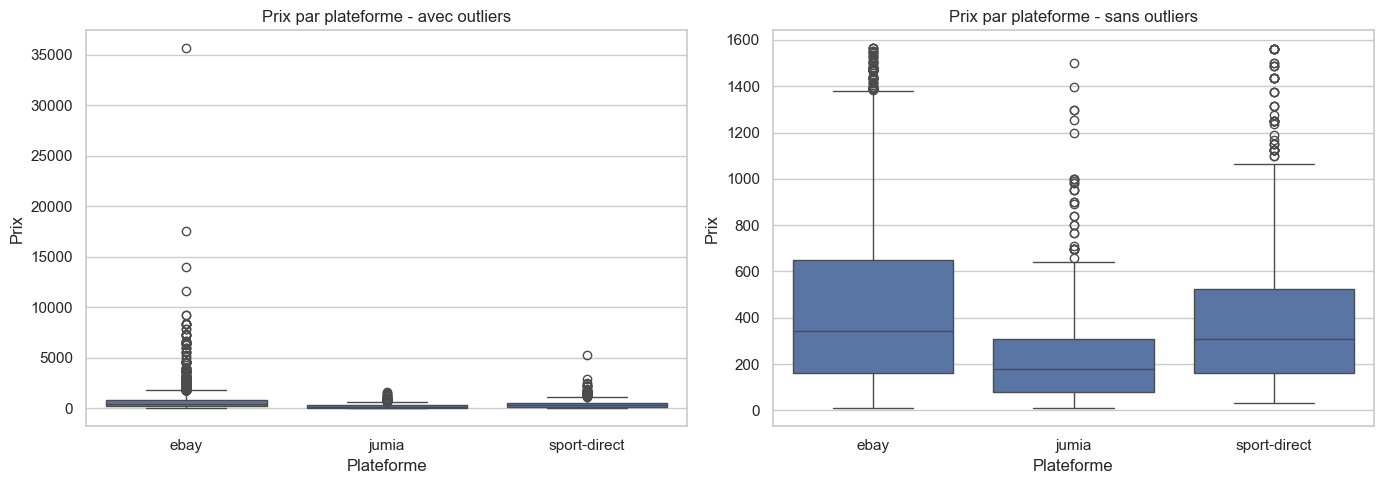

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean_full, x="store", y="price", ax=axes[0])
axes[0].set_title("Prix par plateforme - avec outliers")
axes[0].set_xlabel("Plateforme")
axes[0].set_ylabel("Prix")

sns.boxplot(data=df_clean_no_outliers, x="store", y="price", ax=axes[1])
axes[1].set_title("Prix par plateforme - sans outliers")
axes[1].set_xlabel("Plateforme")
axes[1].set_ylabel("Prix")

plt.tight_layout()

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "02_comparaison_outliers_boxplot.png", dpi=150, bbox_inches="tight")

plt.show()

## 14. Statistiques finales du dataset nettoyé

In [17]:
clean_summary_by_store = df_clean_no_outliers.groupby("store")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index().rename(columns={"store": "plateforme"})

clean_summary_by_category = df_clean_no_outliers.groupby("category")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index().rename(columns={"category": "categorie"})

display(clean_summary_by_store)
display(clean_summary_by_category)

,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,ebay,3635,454.376713,342.060,9.16,1563.25,364.333841
1,jumia,584,241.418545,179.995,9.00,1499.00,226.119543
2,sport-direct,671,411.608823,306.250,31.25,1562.50,341.481709


,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,basketball,658,402.350076,284.945,9.16,1563.25,341.009401
1,combat-sports,843,342.838197,229.000,9.00,1563.25,328.072010
2,football,835,487.815497,369.910,9.16,1563.25,367.823855
3,gym,716,322.960587,277.410,53.74,1435.23,243.585586
4,racket-sports,328,508.407652,321.625,18.79,1562.50,453.045500
5,unknown,1191,463.874542,369.540,9.16,1563.25,364.750237
6,volleyball,319,493.041818,371.020,9.16,1500.00,368.537989


## 15. Audit final du nettoyage

In [18]:
cleaning_audit = pd.DataFrame({
    "metric": [
        "lignes_chargees_apres_validation_base",
        "lignes_apres_filtres_obligatoires",
        "doublons_supprimes",
        "outliers_detectes",
        "lignes_dataset_final_avec_outliers_marques",
        "lignes_dataset_final_sans_outliers",
        "prix_max_avec_outliers",
        "prix_max_sans_outliers",
    ],
    "value": [
        len(df_raw),
        rows_after_required_filters,
        rows_before_dedup - rows_after_dedup,
        int(outlier_count),
        len(df_clean_full),
        len(df_clean_no_outliers),
        df_clean_full["price"].max(),
        df_clean_no_outliers["price"].max(),
    ]
})

print("Audit final du nettoyage :")
cleaning_audit

Audit final du nettoyage :


,metric,value
0,lignes_chargees_apres_validation_base,23166.00
1,lignes_apres_filtres_obligatoires,23166.00
2,doublons_supprimes,17848.00
3,outliers_detectes,428.00
4,lignes_dataset_final_avec_outliers_marques,5318.00
5,lignes_dataset_final_sans_outliers,4890.00
6,prix_max_avec_outliers,35612.50
7,prix_max_sans_outliers,1563.25


## 16. Sauvegarde automatique des datasets nettoyés

In [19]:
if AUTO_SAVE:
    df_clean_full.to_csv(OUTPUT_CLEANED / "02_clean_prices_with_outlier_flag.csv", index=False, encoding="utf-8-sig")
    df_clean_no_outliers.to_csv(OUTPUT_CLEANED / "02_clean_prices_no_outliers.csv", index=False, encoding="utf-8-sig")

    cleaning_audit.to_csv(OUTPUT_TABLES / "02_cleaning_audit.csv", index=False, encoding="utf-8-sig")
    missing_after_standardization.to_csv(OUTPUT_TABLES / "02_missing_after_standardization.csv", index=False, encoding="utf-8-sig")
    comparison_outliers.to_csv(OUTPUT_TABLES / "02_outlier_comparison.csv", index=False, encoding="utf-8-sig")
    clean_summary_by_store.to_csv(OUTPUT_TABLES / "02_clean_price_by_store.csv", index=False, encoding="utf-8-sig")
    clean_summary_by_category.to_csv(OUTPUT_TABLES / "02_clean_price_by_category.csv", index=False, encoding="utf-8-sig")

    print("Sauvegarde terminée.")
    print("Dataset avec outliers marqués :", OUTPUT_CLEANED / "02_clean_prices_with_outlier_flag.csv")
    print("Dataset sans outliers :", OUTPUT_CLEANED / "02_clean_prices_no_outliers.csv")
    print("Tableaux de nettoyage :", OUTPUT_TABLES)
    print("Graphiques :", OUTPUT_FIGURES)
else:
    print("Auto-sauvegarde désactivée.")

Sauvegarde terminée.
Dataset avec outliers marqués : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\cleaned_data\02_clean_prices_with_outlier_flag.csv
Dataset sans outliers : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\cleaned_data\02_clean_prices_no_outliers.csv
Tableaux de nettoyage : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Graphiques : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures


## 17. Conclusion - Data Cleaning

À compléter après exécution du notebook :

- Les colonnes texte ont été standardisées.
- Les variables numériques ont été validées.
- Les prix invalides ou manquants ont été exclus car le prix est obligatoire pour l'analyse.
- Les doublons basés sur plateforme/catégorie/nom/prix ont été supprimés.
- Les outliers de prix ont été détectés avec la méthode IQR.
- Deux datasets ont été sauvegardés : un dataset complet avec indicateur d'outlier et un dataset sans outliers pour les analyses robustes.

**Prochaine phase :** `03_exploratory_analysis.ipynb`, pour produire les visualisations et KPI analytiques à partir du dataset nettoyé.